In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
#global variables
actions_int_to_string= {
    0: "City",
    1: "Settlement",
    2: "Longest Road",
    3: "Dev Card",
    4: "Do Nothing"
}

In [3]:
# TODO: Add summary plot and timeline for all 3 groups
group_3 = './latest_model/shapley_data/group_3/sample_1000.0/shapley_values_group_3.csv'
group_2 = './latest_model/shapley_data/group_2/sample_1000/shapley_values_group_2.csv'
group_1 = './latest_model/shapley_data/small_strat/sample_1000/shapley_values_small_strat.csv'

group_3_npy = './shapley_data/group_3/sample_1000.0/pred_explain_group_3.npy'

In [4]:
group_3_rename= {
    "p0_vps":"P0 Features",
    "p1_vps":"P1 Features",
    "turn_features": "Turn Features",
    "graph_features": "Graph Features",
    "board_features": "Board Features"
}

group_2_rename ={
    "p0_hand_and_pieces": "P0 Hand and Pieces",
    "p1_hand_and_pieces": "P1 Hand and Pieces",
    "turn_features": "Turn Features",
    "p0_vps": "P0 Victory Points",
    "p1_vps": "P1 Victory Points",
    "board_features": "Board Features",
    "graph_features":"Graph Features",
    "p0_dev_cards_played": "P0 Dev Cards Played",
    "p1_dev_cards_played": "P1 Dev Cards Played"
}
group_1_rename ={
    "p0_pieces_and_hand": "P0 Hand and Pieces",
    "p1_pieces_and_hand": "P1 Hand and Pieces",
    "p0_settlements":"P0 Settlements",
    "p1_settlements":"P1 Settlements",
    "p0_cities":"P0 Cities",
    "p1_cities":"P1 Cities",
    "p0_roads":"P0 Roads",
    "p1_roads":"P1 Roads",
    "p0_vps":"P0 Victory Points",
    "p1_public_vps": "P1 Victory Points",
    "p0_devs_played":"P0 Dev Cards Played",
    "p1_devs_played":"P1 Dev Cards Played",
    "bank":"Bank",
    "tile_features":"Tile Features",
    "rolled_and_robber": "Turn Features"
}

In [5]:
df_g1 = pd.read_csv(group_1)
df_g2 = pd.read_csv(group_2)
df_g3 = pd.read_csv(group_3)

df_g1.drop(columns=['none', 'Unnamed: 0'],axis=1,inplace=True)
df_g2.drop(columns=['none', 'Unnamed: 0'],axis=1,inplace=True)
df_g3.drop(columns=['none', 'Unnamed: 0'],axis=1,inplace=True)

df_g3 =df_g3.rename(columns=group_3_rename)
df_g2 =df_g2.rename(columns=group_2_rename)
df_g1 =df_g1.rename(columns=group_1_rename)


df_g3

,Board Features,Graph Features,Turn Features,P0 Features,P1 Features
0,-0.141093,0.056406,0.178551,0.005449,-0.318491
1,-0.135878,-0.111397,0.148104,0.264708,-0.384716
2,-0.040339,-0.148613,0.780385,1.150377,0.039012
3,-0.069144,0.016335,0.111207,-0.210004,-0.067572
4,0.371253,0.007948,-0.270587,-0.299402,-0.028390
...,...,...,...,...,...
68,0.283382,0.143377,-0.273131,-0.463552,0.090746
69,-0.495690,-0.145157,-0.574601,0.224358,-0.228088
70,-0.199345,-0.328244,-0.396091,0.837166,-0.132664
71,-0.258522,-0.018703,0.782060,0.444413,-0.168426


In [6]:
g3_npy = np.load(group_3_npy)
g3_npy

array([3., 3., 1., 0., 0., 1., 3., 0., 1., 1., 4., 4., 0., 0., 3., 1., 1.,
       1., 1., 1., 2., 1., 3., 3., 2., 0., 4., 1., 1., 4., 3., 1., 1., 1.,
       1., 1., 1., 0., 1., 1., 0., 3., 3., 1., 3., 1., 0., 2., 1., 1., 1.,
       1., 3., 4., 2., 4., 0., 1., 1., 1., 1., 4., 1., 3., 3., 4., 1., 3.,
       1., 1., 1., 1., 1.])

In [56]:
data = [
    ["group(n=5)", 1.0769220982980234, 0.20439103843331002, "Good"],
    ["group(n=5)",1.0813420480943265,'Bad'],
    ["group(n=5)",1.136679107755047,'Random'],
    ["group(n=9)", 1.0625164477257603, 0.199026881026613,'Good'],
    ["group(n=9)", 1.0825256133016845,'Bad'],
    ["group(n=9)", 1.1131009015882338,'Random'],
    ["group(n=15)", 1.1134212209764665,'Good'],
    ["group(n=15)", 1.1,'Bad'],
    ["group(n=15)", 1.1230993472930972,'Random']
]
data = [
    ["group(n=5)", 0.805245,0.06070009797256602, "Good"],
    ["group(n=5)",0.9099,'Bad'],
    ["group(n=5)",0.763928,'Random'],
    ["group(n=9)", 0.812596, 0.04681665388827076,'Good'],
    ["group(n=9)", 0.895713,'Bad'],
    ["group(n=9)", 0.840612,'Random'],
    ["group(n=15)", 0.8649600473064282, 0.1466448270972834,'Good'],
    ["group(n=15)", 1.1,'Bad'],
    ["group(n=15)", 1.1230993472930972,'Random']
]

data = [
    ["group(n=5)", 0.7236613,0.06070009797256602,173, "Good"],
    ["group(n=5)",0.7494717 ,0.06722185487424306,173,'Bad'],
    ["group(n=5)",0.7675038, 0.07246710324744023,173,'Random'],
    ["group(n=9)", 0.7107784, 0.04681665388827076,300,'Good'],
    ["group(n=9)", 0.7404495,0.05759883757277336,300,'Bad'],
    ["group(n=9)", 0.7662284,0.06508150199323678,300,'Random'],
    ["group(n=15)", 0.7114755, 0.032409334862495405,300,'Good'],
    ["group(n=15)", 0.7441163,0.07309667020330969,300,'Bad'],
    ["group(n=15)", 0.7654832,0.0661714895055274,300,'Random']
]

# data = [
#     ["group(n=5)",92.75463799999999, "Good"],
#     ["group(n=5)",87.10402200000001,'Bad'],
#     ["group(n=5)",89.20470200000001,'Random'],
#     ["group(n=9)", 1400.01395,'Good'],
#     ["group(n=9)", 1358.129354,'Bad'],
#     ["group(n=9)", 1414.266967,'Random'],
#     ["group(n=15)", 110725.54756500002,'Good'],
#     ["group(n=15)", 107683.445171,'Bad'],
#     ["group(n=15)", 108660.400948,'Random']
# ]
df = pd.DataFrame(data=data,columns=["group","MSEv","std",'nob',"Group Type"])
df

,group,MSEv,std,nob,Group Type
0,group(n=5),0.723661,0.060700,173,Good
1,group(n=5),0.749472,0.067222,173,Bad
2,group(n=5),0.767504,0.072467,173,Random
3,group(n=9),0.710778,0.046817,300,Good
4,group(n=9),0.740449,0.057599,300,Bad
5,group(n=9),0.766228,0.065082,300,Random
6,group(n=15),0.711476,0.032409,300,Good
7,group(n=15),0.744116,0.073097,300,Bad
8,group(n=15),0.765483,0.066171,300,Random


In [92]:
from scipy import stats
samp1 =7
samp2 =8

mean1 = df['MSEv'][samp1]
sdt1 = df["std"][samp1]
nob1 =73
nob1 = df["nob"][samp1]

mean2 = df['MSEv'][samp2]
sdt2 = df["std"][samp2]
nob2 = 73
nob2 = df["nob"][samp2]

ttest = stats.ttest_ind_from_stats(mean1=mean1,std1=sdt1, nobs1=nob1, mean2=mean2, std2=sdt2, nobs2=nob2,equal_var=False)

print(df.iloc[samp1])
print('------------------------------------')
print("vs")
print('------------------------------------')
print( df.iloc[samp2])
print(ttest)

group         group(n=15)
MSEv             0.744116
std              0.073097
nob                   300
Group Type            Bad
Name: 7, dtype: object
------------------------------------
vs
------------------------------------
group         group(n=15)
MSEv             0.765483
std              0.066171
nob                   300
Group Type         Random
Name: 8, dtype: object
Ttest_indResult(statistic=-3.7534362537351944, pvalue=0.00019161420529854433)


Text(0.5, 0, 'Feature Groupings')

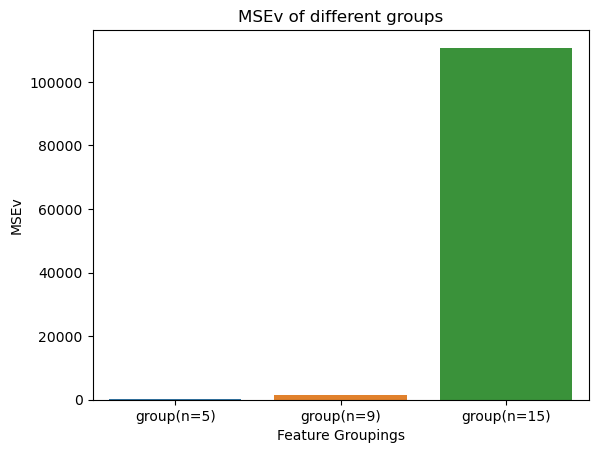

In [9]:
sns.barplot(data=df[df['Group Type'] == "Good"], x='group',y='MSEv',palette='tab10')
# sns.barplot(data=df, x='group',y='MSEv',palette='tab10',hue="Group Type")
plt.title("MSEv of different groups")
plt.xlabel("Feature Groupings")

Text(0.5, 0, '|Mean Shapley Value|')

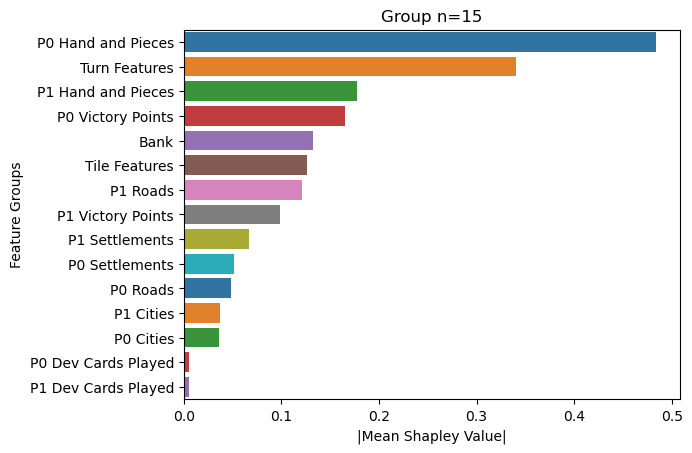

In [10]:
g1_sum = df_g1.abs().mean().sort_values(ascending=False)
sns.barplot(x=g1_sum.values,y=g1_sum.index,palette='tab10')
plt.title("Group n=15")
plt.ylabel('Feature Groups')
plt.xlabel('|Mean Shapley Value|')

Text(0.5, 0, '|Mean Shapley Value|')

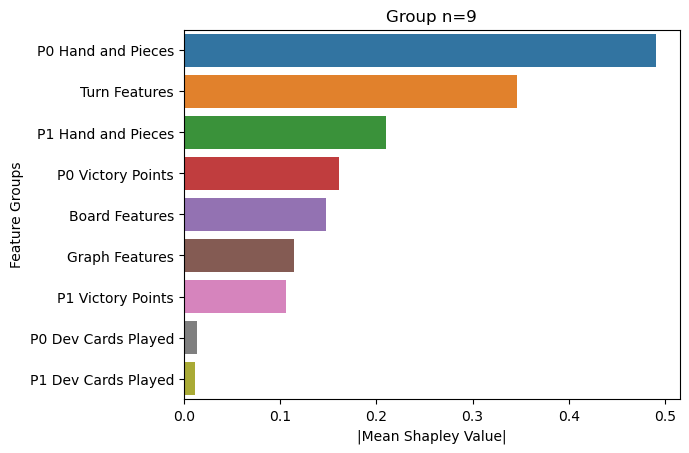

In [11]:
g1_sum = df_g2.abs().mean().sort_values(ascending=False)
sns.barplot(x=g1_sum.values,y=g1_sum.index,palette='tab10')
plt.title("Group n=9")
plt.ylabel('Feature Groups')
plt.xlabel('|Mean Shapley Value|')

,Board Features,Graph Features,Turn Features,P0 Features,P1 Features
0,-0.141093,0.056406,0.178551,0.005449,-0.318491
1,-0.135878,-0.111397,0.148104,0.264708,-0.384716
2,-0.040339,-0.148613,0.780385,1.150377,0.039012
3,-0.069144,0.016335,0.111207,-0.210004,-0.067572
4,0.371253,0.007948,-0.270587,-0.299402,-0.028390
...,...,...,...,...,...
68,0.283382,0.143377,-0.273131,-0.463552,0.090746
69,-0.495690,-0.145157,-0.574601,0.224358,-0.228088
70,-0.199345,-0.328244,-0.396091,0.837166,-0.132664
71,-0.258522,-0.018703,0.782060,0.444413,-0.168426


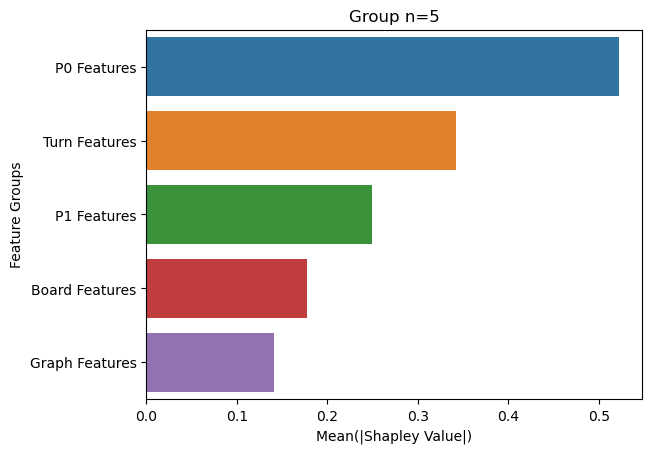

In [12]:
# change group 3 labels to be user friendly
# df_g3 =df_g3.rename(columns={'p0_vps':'p0 features','p1_vps':'p1 features'})
g1_sum = df_g3.abs().mean().sort_values(ascending=False)
sns.barplot(x=g1_sum.values,y=g1_sum.index,palette='tab10')
plt.title("Group n=5")
plt.ylabel('Feature Groups')
plt.xlabel('Mean(|Shapley Value|)')
df_g3

Board Features        -0.017247
Graph Features        -0.019581
Turn Features         -0.002371
P0 Victory Points     -0.011670
P1 Victory Points      0.030756
P0 Hand and Pieces     0.007347
P1 Hand and Pieces     0.022994
P0 Dev Cards Played   -0.005499
P1 Dev Cards Played   -0.004729
dtype: float64
[ 0.45111299 -0.10040302 -0.0180551  -0.06875939  0.20632511 -0.07742334
 -0.05433131 -0.00589922 -0.29180962  0.22698454  0.13749321  1.22617645
  0.1725893  -0.01283795 -0.01034087]
Board Features    0.177467
Graph Features    0.141271
Turn Features     0.341905
P0 Features       0.521492
P1 Features       0.249403
dtype: float64
[ 0.45111299 -0.10040302 -0.0180551  -0.06875939  0.20632511 -0.07742334
 -0.05433131 -0.00589922 -0.29180962  0.22698454  0.13749321  1.22617645
  0.1725893  -0.01283795 -0.01034087]


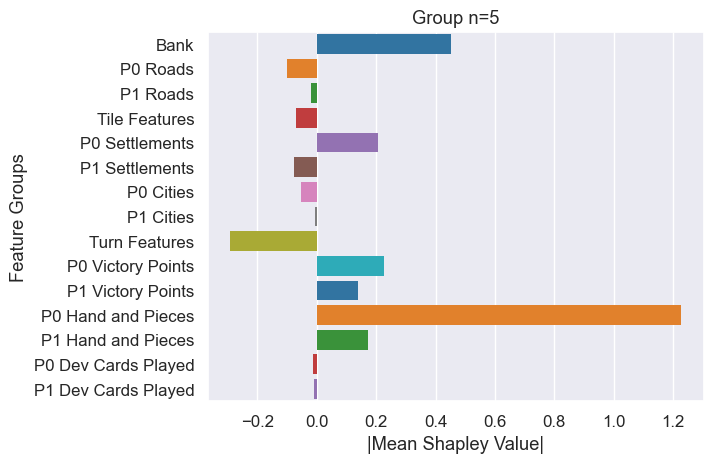

0
abs_val:
 P1 Features       0.318491
Turn Features     0.178551
Board Features    0.141093
Graph Features    0.056406
P0 Features       0.005449
Name: 0, dtype: float64
abs_mean:
 Board Features    0.177467
Graph Features    0.141271
Turn Features     0.341905
P0 Features       0.521492
P1 Features       0.249403
dtype: float64
Ans:
 P1 Features       0.069087
Board Features   -0.036373
Graph Features   -0.084865
Turn Features    -0.163354
P0 Features      -0.516043
dtype: float64
1
abs_val:
 P1 Features       0.384716
P0 Features       0.264708
Turn Features     0.148104
Board Features    0.135878
Graph Features    0.111397
Name: 1, dtype: float64
abs_mean:
 Board Features    0.177467
Graph Features    0.141271
Turn Features     0.341905
P0 Features       0.521492
P1 Features       0.249403
dtype: float64
Ans:
 P1 Features       0.135313
Graph Features   -0.029874
Board Features   -0.041589
Turn Features    -0.193800
P0 Features      -0.256784
dtype: float64
2
abs_val:
 P0 Features 

In [21]:
df_g3
def mean_surrounding_rows(df, row_index, window=5):
    start = max(row_index - (window // 2), 0)  # Ensure we don't go below index 0
    end = min(row_index + (window // 2) + 1, len(df))  # Ensure we don't exceed DataFrame size
    surrounding_rows = df.iloc[start:end]
    return surrounding_rows.mean()

# Specify the row index
row_index = 10

# Get the mean of 5 rows around the specified row
local_mean = mean_surrounding_rows(df_g2, 31)
# temp =np.abs(df_g2.iloc[31].values)
temp =df_g1.iloc[31].values
mean = df_g2.mean()
print(mean)
# temp =temp.abs().mean()
print(temp)
# temp = temp- mean
# print(temp2)
print(df_g3.abs().mean())
print(temp)
df_g3.columns
sns.barplot(x=temp,y=df_g1.columns,palette='tab10')
plt.title("Group n=5")
plt.ylabel('Feature Groups')
plt.xlabel('|Mean Shapley Value|')
plt.show()
# colors = ['blue' if x >= 0 else 'red' for x in df['Values']]

def single_state_bar(df = df_g3, row_index=0, group:str ="group"):
    #get values of ingex and abs it
    abs_val = df.iloc[row_index].abs()
    abs_val = df.iloc[row_index].abs().sort_values(ascending=False)
    # val = df.iloc[row_index].sort_values(ascending=False)
    val = df.iloc[row_index]
    # print(val)
    # print("dasdas",df.columns)

    # get mean of data
    mean = df.mean()
    abs_mean = df.abs().mean()
    local_mean = mean_surrounding_rows(df,row_index)
    print("abs_val:\n",abs_val)
    print("abs_mean:\n",abs_mean)
    #subtract mean from data
    sub_mean_val = abs_val - abs_mean
    sub_mean_val = sub_mean_val.sort_values(ascending=False)
    print("Ans:\n",sub_mean_val)

    # sub_mean_val = val - abs_mean
    # sub_mean_val = val - mean
    # sub_mean_val = sub_mean_val.sort_values(ascending=False)
    
    abs_sub_mean_val = val - mean
    abs_sub_mean_val = abs_sub_mean_val.abs().sort_values(ascending=False)
    colors = ['red' if val < 0 else 'blue' for val in sub_mean_val]
    sns.set(font_scale=1.3)
    sns.set_context(rc = {'patch.linewidth': 0.0})
    # plt.style.use('default')
    # plt.rcParams.update({'font.size': 50})
    # sns.barplot(x=val,y=val.index,color='red')
    sns.barplot(x=abs_val,y=abs_val.index,color='blue')
    # sns.barplot(x=sub_mean_val,y=sub_mean_val.index,palette=colors)
    # sns.barplot(x=abs_sub_mean_val,y=abs_sub_mean_val.index,color='red')
    plt.title("Action: Longest Road Play-style")
    plt.ylabel('Feature Groups')
    
    plt.xlabel('|Shapley Value|')
    # plt.xlabel('|Shapley Value| - mean(|Shapley Value|)')
    plt.tight_layout()
    # plt.show()
    plt.savefig(f"./images/latest_model/{group}/step_{row_index}.svg")
    plt.close()

# single_state_bar(df_g2,31)

def gen_bars_for_game(df: pd.DataFrame,group:str='group'):
    for index, row in df.iterrows():
        print(index)
        single_state_bar(df, index,group)

# gen_bars_for_game(df_g1,"group_1")
# gen_bars_for_game(df_g2,"group_2")
gen_bars_for_game(df_g3,"group_3")

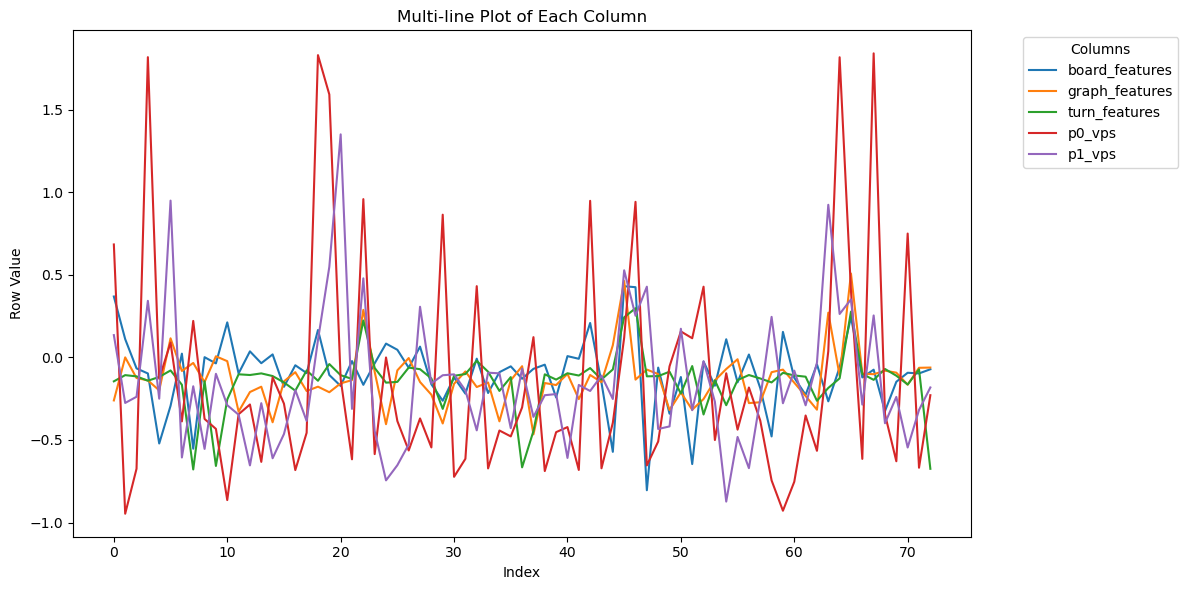

In [27]:
plt.figure(figsize=(12, 6))

for column in df_g3.columns:
    plt.plot(df_g3.index, df_g3[column], label=column)

plt.xlabel("Index")
plt.ylabel("Row Value")
plt.title("Multi-line Plot of Each Column")
plt.legend(title="Columns", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

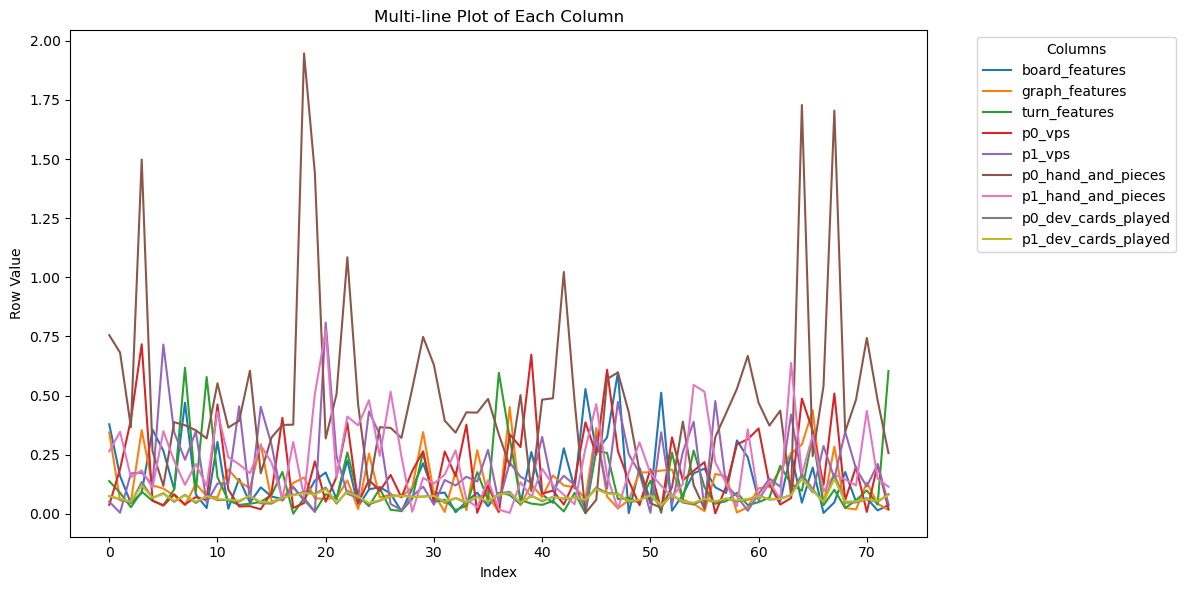

In [14]:
plt.figure(figsize=(12, 6))

for column in df_g2.columns:
    plt.plot(df_g2.index, df_g2[column].abs(), label=column)

plt.xlabel("Index")
plt.ylabel("Row Value")
plt.title("Multi-line Plot of Each Column")
plt.legend(title="Columns", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

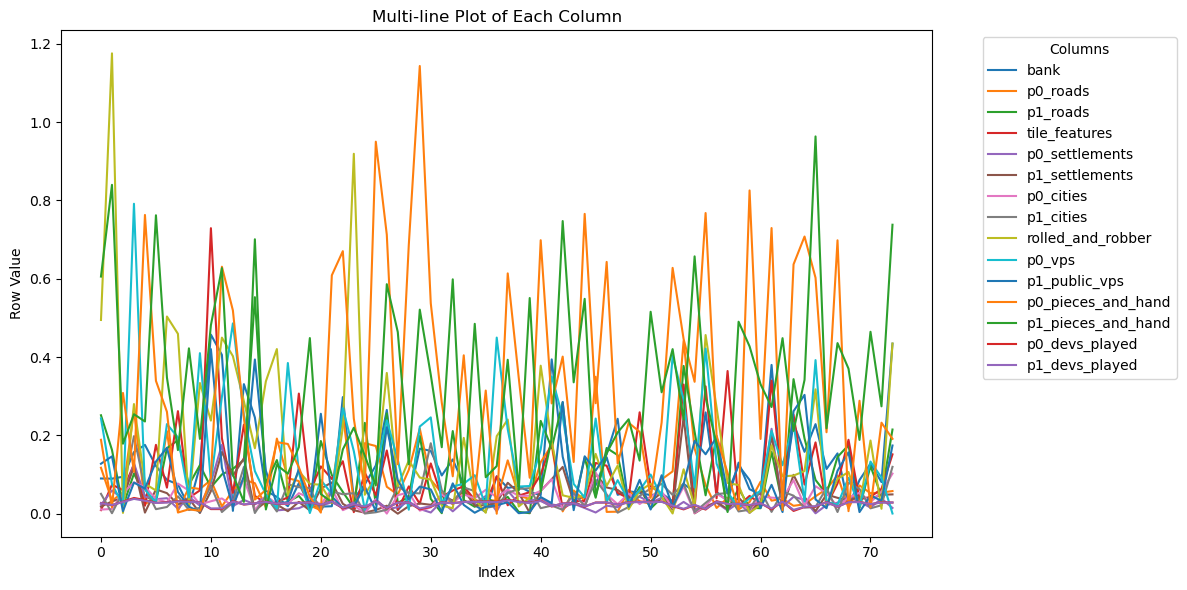

In [21]:
plt.figure(figsize=(12, 6))

for column in df_g1.columns:
    plt.plot(df_g1.index, df_g1[column].abs(), label=column)

plt.xlabel("Index")
plt.ylabel("Row Value")
plt.title("Multi-line Plot of Each Column")
plt.legend(title="Columns", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

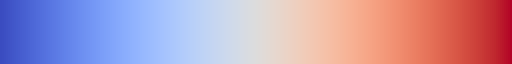

In [44]:
sns.color_palette("coolwarm", as_cmap=True)